# 8-Metric Figures with Subtle A-vs-C Highlight and Best-Condition Marker

This notebook extends the modern multi-panel figure design and adds two new ideas:

## 1) Subtle A vs C emphasis
For each metric panel:
- A and C are softly highlighted
- the **A→C mean difference** is shown in a compact annotation
- if available, the **global post-hoc FDR q-value** for A vs C is shown

The goal is to make the A–C contrast more visible **without being too strong**.

## 2) Best-condition marker
For each metric panel, the notebook marks the **best condition** according to a configurable rule.

Because "better" depends on the metric, the notebook uses an editable dictionary:

- **higher is better** for metrics like VAI, Time spent, Fixations, Revisits
- **lower is better** for metrics like TTFF
- some metrics can be changed manually if you prefer a different interpretation

## Outputs
The notebook automatically creates **3 PDFs** and matching PNGs:

- `CTA_8metrics_AC_best.pdf`
- `Headline_8metrics_AC_best.pdf`
- `Product_8metrics_AC_best.pdf`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats


## 1. Configuration

In [2]:
LONG_CSV = "data/A_to_E_long_image_level_data.csv"
POSTHOC_CSV = "data/A_to_E_repeated_measures_posthoc.csv"

CONDITION_ORDER = ["A", "B", "C", "D", "E"]

AOIS = [
    "CTA",
    "Headline",
    "Product",
]

METRICS = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "FFD (s)",
    "K-coefficient",
    "Revisits",
]

# This controls which direction is interpreted as "better".
# Edit any metric here if you prefer another interpretation.
BETTER_DIRECTION = {
    "VAI (%)": "max",
    "TTFF (s)": "min",
    "Time spent (s)": "max",
    "Fixations": "max",
    "Fix. duration (s)": "min",
    "FFD (s)": "min",
    "K-coefficient": "max",
    "Revisits": "max",
}

# Comparisons to annotate if significant.
SIGNIFICANCE_PAIRS = [
    ("A", "C"),
    ("B", "C"),
    ("C", "D"),
    ("C", "E"),
]

SHOW_MATCHED_LINES = True
SHOW_MEAN_LABELS = True
SHOW_AC_DELTA = True
SHOW_BEST_MARKER = True

RANDOM_SEED = 42


## 2. Load data

In [3]:
for f in [LONG_CSV, POSTHOC_CSV]:
    if not Path(f).exists():
        raise FileNotFoundError(
            f"Could not find {f}. Check the path in the configuration cell."
        )

long_df = pd.read_csv(LONG_CSV)
posthoc = pd.read_csv(POSTHOC_CSV)

for frame in [long_df, posthoc]:
    frame.columns = [str(c).replace("**", "").strip() for c in frame.columns]

long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")

print("AOIs:", sorted(long_df["AOI"].dropna().unique()))
print("Metrics:", sorted(long_df["metric"].dropna().unique()))
print("Rows:", len(long_df))


AOIs: ['CTA', 'Headline', 'Product']
Metrics: ['FFD (s)', 'Fix. duration (s)', 'Fixations', 'K-coefficient', 'Revisits', 'TTFF (s)', 'Time spent (s)', 'VAI (%)']
Rows: 2400


## 3. Helper functions

In [4]:
def get_focus(aoi, metric):
    df = long_df[
        (long_df["AOI"] == aoi)
        & (long_df["metric"] == metric)
        & (long_df["condition"].isin(CONDITION_ORDER))
    ].copy()
    return df.dropna(subset=["value"])


def get_summary(focus_df):
    rows = []

    for cond in CONDITION_ORDER:
        vals = (
            focus_df.loc[focus_df["condition"] == cond, "value"]
            .dropna()
            .astype(float)
            .values
        )

        n = len(vals)

        if n == 0:
            rows.append({
                "condition": cond,
                "n": 0,
                "mean": np.nan,
                "sd": np.nan,
                "ci95": np.nan,
                "lower": np.nan,
                "upper": np.nan,
            })
            continue

        mean = np.mean(vals)
        sd = np.std(vals, ddof=1) if n > 1 else np.nan

        if n > 1:
            se = sd / np.sqrt(n)
            tcrit = stats.t.ppf(0.975, df=n - 1)
            ci = tcrit * se
        else:
            ci = np.nan

        rows.append({
            "condition": cond,
            "n": n,
            "mean": mean,
            "sd": sd,
            "ci95": ci,
            "lower": mean - ci if np.isfinite(ci) else np.nan,
            "upper": mean + ci if np.isfinite(ci) else np.nan,
        })

    return pd.DataFrame(rows)


def get_pivot(focus_df):
    return (
        focus_df.pivot(index="Img", columns="condition", values="value")
        .reindex(columns=CONDITION_ORDER)
    )


def get_pair_row(aoi, metric, g1, g2):
    mask = (
        (posthoc["AOI"] == aoi)
        & (posthoc["metric"] == metric)
        & (
            ((posthoc["group1"] == g1) & (posthoc["group2"] == g2))
            | ((posthoc["group1"] == g2) & (posthoc["group2"] == g1))
        )
    )

    rows = posthoc.loc[mask]
    return None if len(rows) == 0 else rows.iloc[0]


def format_q(q):
    if pd.isna(q):
        return ""
    if q < 0.001:
        return "q < .001"
    return f"q = {q:.3f}"


def deterministic_jitter(n, width=0.080):
    if n <= 1:
        return np.zeros(n)
    return np.linspace(-width, width, n)


def best_condition(summary_df, metric):
    direction = BETTER_DIRECTION.get(metric, "max")
    temp = summary_df[["condition", "mean"]].dropna().copy()

    if len(temp) == 0:
        return None, np.nan

    if direction == "min":
        idx = temp["mean"].idxmin()
    else:
        idx = temp["mean"].idxmax()

    row = temp.loc[idx]
    return row["condition"], row["mean"]


def mean_label_value(x):
    if not np.isfinite(x):
        return ""
    if abs(x) < 10:
        return f"{x:.2f}"
    return f"{x:.1f}"


def get_ylabel(metric):
    return metric


## 4. Draw one panel

In [5]:
def draw_metric_panel(ax, aoi, metric, panel_index, condition_colors):
    focus = get_focus(aoi, metric)

    if focus.empty:
        ax.set_visible(False)
        return

    summary = get_summary(focus)
    pivot = get_pivot(focus)

    x_positions = {c: i for i, c in enumerate(CONDITION_ORDER)}

    # --------------------------------------------------
    # Subtle emphasis for A and C
    # --------------------------------------------------
    ax.axvspan(
        x_positions["A"] - 0.28,
        x_positions["A"] + 0.28,
        alpha=0.018,
        zorder=0
    )

    ax.axvspan(
        x_positions["C"] - 0.30,
        x_positions["C"] + 0.30,
        alpha=0.040,
        zorder=0
    )

    # --------------------------------------------------
    # Matched-image trajectories
    # --------------------------------------------------
    if SHOW_MATCHED_LINES:
        complete = pivot.dropna()
        for _, row in complete.iterrows():
            ax.plot(
                np.arange(len(CONDITION_ORDER)),
                row[CONDITION_ORDER].astype(float).values,
                linewidth=0.50,
                alpha=0.055,
                zorder=1
            )

    # --------------------------------------------------
    # Raw observations
    # --------------------------------------------------
    rng = np.random.default_rng(RANDOM_SEED + panel_index)

    for cond in CONDITION_ORDER:
        vals = (
            focus.loc[focus["condition"] == cond, "value"]
            .dropna()
            .astype(float)
            .sort_values()
            .values
        )

        x0 = x_positions[cond]
        jitter = deterministic_jitter(len(vals), width=0.080)

        if len(jitter) > 1:
            jitter = jitter[rng.permutation(len(jitter))]

        ax.scatter(
            np.full(len(vals), x0) + jitter,
            vals,
            s=23,
            alpha=0.44,
            color=condition_colors[cond],
            edgecolors="white",
            linewidths=0.38,
            zorder=3
        )

    # --------------------------------------------------
    # Mean trajectory
    # --------------------------------------------------
    mean_values = [
        summary.loc[summary["condition"] == c, "mean"].iloc[0]
        for c in CONDITION_ORDER
    ]

    ax.plot(
        np.arange(len(CONDITION_ORDER)),
        mean_values,
        linewidth=2.10,
        alpha=0.86,
        zorder=4,
        path_effects=[
            pe.Stroke(linewidth=3.7, foreground="white"),
            pe.Normal()
        ]
    )

    # --------------------------------------------------
    # Slightly highlight the A→C segment
    # --------------------------------------------------
    if SHOW_AC_DELTA:
        mean_A = summary.loc[summary["condition"] == "A", "mean"].iloc[0]
        mean_C = summary.loc[summary["condition"] == "C", "mean"].iloc[0]

        if np.isfinite(mean_A) and np.isfinite(mean_C):
            ax.plot(
                [x_positions["A"], x_positions["C"]],
                [mean_A, mean_C],
                linewidth=2.55,
                alpha=0.32,
                zorder=5,
                linestyle="-",
                path_effects=[
                    pe.Stroke(linewidth=4.4, foreground="white"),
                    pe.Normal()
                ]
            )

    # --------------------------------------------------
    # Means + 95% CI
    # --------------------------------------------------
    for _, r in summary.iterrows():
        cond = r["condition"]
        x = x_positions[cond]

        ax.errorbar(
            x,
            r["mean"],
            yerr=r["ci95"],
            fmt="o",
            markersize=7.2,
            capsize=4.2,
            capthick=1.2,
            elinewidth=1.7,
            color=condition_colors[cond],
            markeredgecolor="white",
            markeredgewidth=0.95,
            zorder=6
        )

    data_min = float(focus["value"].min())
    data_max = float(focus["value"].max())
    data_range = max(1e-6, data_max - data_min)

    # --------------------------------------------------
    # Mean labels
    # --------------------------------------------------
    if SHOW_MEAN_LABELS:
        for _, r in summary.iterrows():
            if not np.isfinite(r["mean"]):
                continue

            cond = r["condition"]
            x = x_positions[cond]
            label_y = r["upper"] if np.isfinite(r["upper"]) else r["mean"]

            ax.text(
                x,
                label_y + 0.018 * data_range,
                mean_label_value(r["mean"]),
                ha="center",
                va="bottom",
                fontsize=7.0,
                fontweight="bold",
                color=condition_colors[cond],
                zorder=7,
                bbox=dict(
                    boxstyle="round,pad=0.14",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.88
                )
            )

    # --------------------------------------------------
    # Best-condition marker
    # --------------------------------------------------
    best_cond, best_mean = best_condition(summary, metric)

    if SHOW_BEST_MARKER and best_cond is not None and np.isfinite(best_mean):
        bx = x_positions[best_cond]
        upper = summary.loc[summary["condition"] == best_cond, "upper"].iloc[0]
        by = upper if np.isfinite(upper) else best_mean

        # ring around the winning mean
        ax.scatter(
            [bx],
            [best_mean],
            s=175,
            facecolors="none",
            edgecolors=condition_colors[best_cond],
            linewidths=1.3,
            alpha=0.75,
            zorder=7.5
        )

        direction = BETTER_DIRECTION.get(metric, "max")
        tag = "best ↑" if direction == "max" else "best ↓"

        ax.text(
            bx,
            by + 0.085 * data_range,
            f"{tag}: {best_cond}",
            ha="center",
            va="bottom",
            fontsize=6.8,
            fontweight="bold",
            color=condition_colors[best_cond],
            zorder=9,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.96
            )
        )

    # --------------------------------------------------
    # Significant C-focused post-hoc brackets
    # --------------------------------------------------
    sig_pairs = []

    for g1, g2 in SIGNIFICANCE_PAIRS:
        row = get_pair_row(aoi, metric, g1, g2)
        if row is None:
            continue

        q = pd.to_numeric(
            pd.Series([row.get("q_posthoc_global_FDR")]),
            errors="coerce"
        ).iloc[0]

        sig = bool(row.get("significant_posthoc_global_FDR", False))

        if sig and np.isfinite(q):
            sig_pairs.append((g1, g2, q))

    base_y = data_max + 0.085 * data_range
    step = 0.063 * data_range
    bracket_h = 0.013 * data_range

    for k, (g1, g2, q) in enumerate(sig_pairs):
        x1 = x_positions[g1]
        x2 = x_positions[g2]
        y = base_y + k * step

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + bracket_h, y + bracket_h, y],
            linewidth=0.95,
            zorder=8
        )

        ax.text(
            (x1 + x2) / 2,
            y + bracket_h + 0.006 * data_range,
            format_q(q),
            ha="center",
            va="bottom",
            fontsize=6.4,
            bbox=dict(
                boxstyle="round,pad=0.14",
                facecolor="white",
                edgecolor="none",
                alpha=0.96
            ),
            zorder=9
        )

    # --------------------------------------------------
    # Compact A→C delta note
    # --------------------------------------------------
    if SHOW_AC_DELTA:
        mean_A = summary.loc[summary["condition"] == "A", "mean"].iloc[0]
        mean_C = summary.loc[summary["condition"] == "C", "mean"].iloc[0]
        ac_row = get_pair_row(aoi, metric, "A", "C")

        if np.isfinite(mean_A) and np.isfinite(mean_C):
            delta = mean_C - mean_A

            note = f"A→C Δ = {delta:+.2f}" if abs(delta) < 10 else f"A→C Δ = {delta:+.1f}"

            if ac_row is not None:
                q = pd.to_numeric(
                    pd.Series([ac_row.get("q_posthoc_global_FDR")]),
                    errors="coerce"
                ).iloc[0]
                sig = bool(ac_row.get("significant_posthoc_global_FDR", False))

                if np.isfinite(q):
                    note = note + " · " + format_q(q)

                if sig:
                    note = note + " *"

            ax.text(
                0.995,
                1.005,
                note,
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=7.2,
                alpha=0.72,
                bbox=dict(
                    boxstyle="round,pad=0.16",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.86
                ),
                zorder=10
            )

    upper_limit = base_y + max(1, len(sig_pairs)) * step + 0.095 * data_range
    lower_limit = data_min - 0.040 * data_range

    ax.set_ylim(lower_limit, upper_limit)

    ax.set_title(
        metric,
        loc="left",
        fontweight="bold",
        fontsize=10.8,
        pad=8
    )

    matched_n = len(pivot.dropna())
    ax.text(
        0,
        1.004,
        f"matched images n = {matched_n}",
        transform=ax.transAxes,
        fontsize=7.2,
        va="bottom",
        alpha=0.64
    )

    ax.set_ylabel(get_ylabel(metric), fontsize=8.8)

    ax.set_xticks(np.arange(len(CONDITION_ORDER)))
    ax.set_xticklabels(CONDITION_ORDER, fontweight="bold", fontsize=8.5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.42)
    ax.spines["bottom"].set_alpha(0.42)

    ax.grid(axis="y", linewidth=0.5, alpha=0.09)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", length=0)


## 5. Function to create one AOI figure

In [6]:
def create_aoi_figure(aoi):
    plt.rcParams.update({
        "font.size": 9,
        "axes.titlesize": 10.8,
        "axes.labelsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "axes.linewidth": 0.75,
    })

    cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if len(cycle_colors) < len(CONDITION_ORDER):
        cycle_colors = [f"C{i}" for i in range(len(CONDITION_ORDER))]

    condition_colors = {
        c: cycle_colors[i]
        for i, c in enumerate(CONDITION_ORDER)
    }

    fig, axes = plt.subplots(
        nrows=4,
        ncols=2,
        figsize=(13.0, 17.4)
    )

    axes = axes.flatten()

    for i, metric in enumerate(METRICS):
        draw_metric_panel(
            axes[i],
            aoi,
            metric,
            panel_index=i,
            condition_colors=condition_colors
        )

    for i, ax in enumerate(axes):
        if i < 6:
            ax.set_xlabel("")
        else:
            ax.set_xlabel("Condition", fontsize=9)

    fig.suptitle(
        f"{aoi} gaze metrics across conditions A–E",
        x=0.065,
        y=0.995,
        ha="left",
        fontsize=17,
        fontweight="bold"
    )

    fig.text(
        0.065,
        0.980,
        "Image-level gaze responses · subtle A–C emphasis · best-condition marker · raw observations · matched-image trajectories · mean ± 95% CI",
        fontsize=9.5,
        alpha=0.72
    )

    fig.tight_layout(
        rect=[0.035, 0.035, 0.995, 0.965],
        h_pad=2.35,
        w_pad=2.0
    )

    output_png = f"{aoi}_8metrics_AC_best.png"
    output_pdf = f"{aoi}_8metrics_AC_best.pdf"

    fig.savefig(
        output_png,
        dpi=500,
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        output_pdf,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

    print("Saved:", output_png)
    print("Saved:", output_pdf)


## 6. Generate all three figures


Creating figure for: CTA


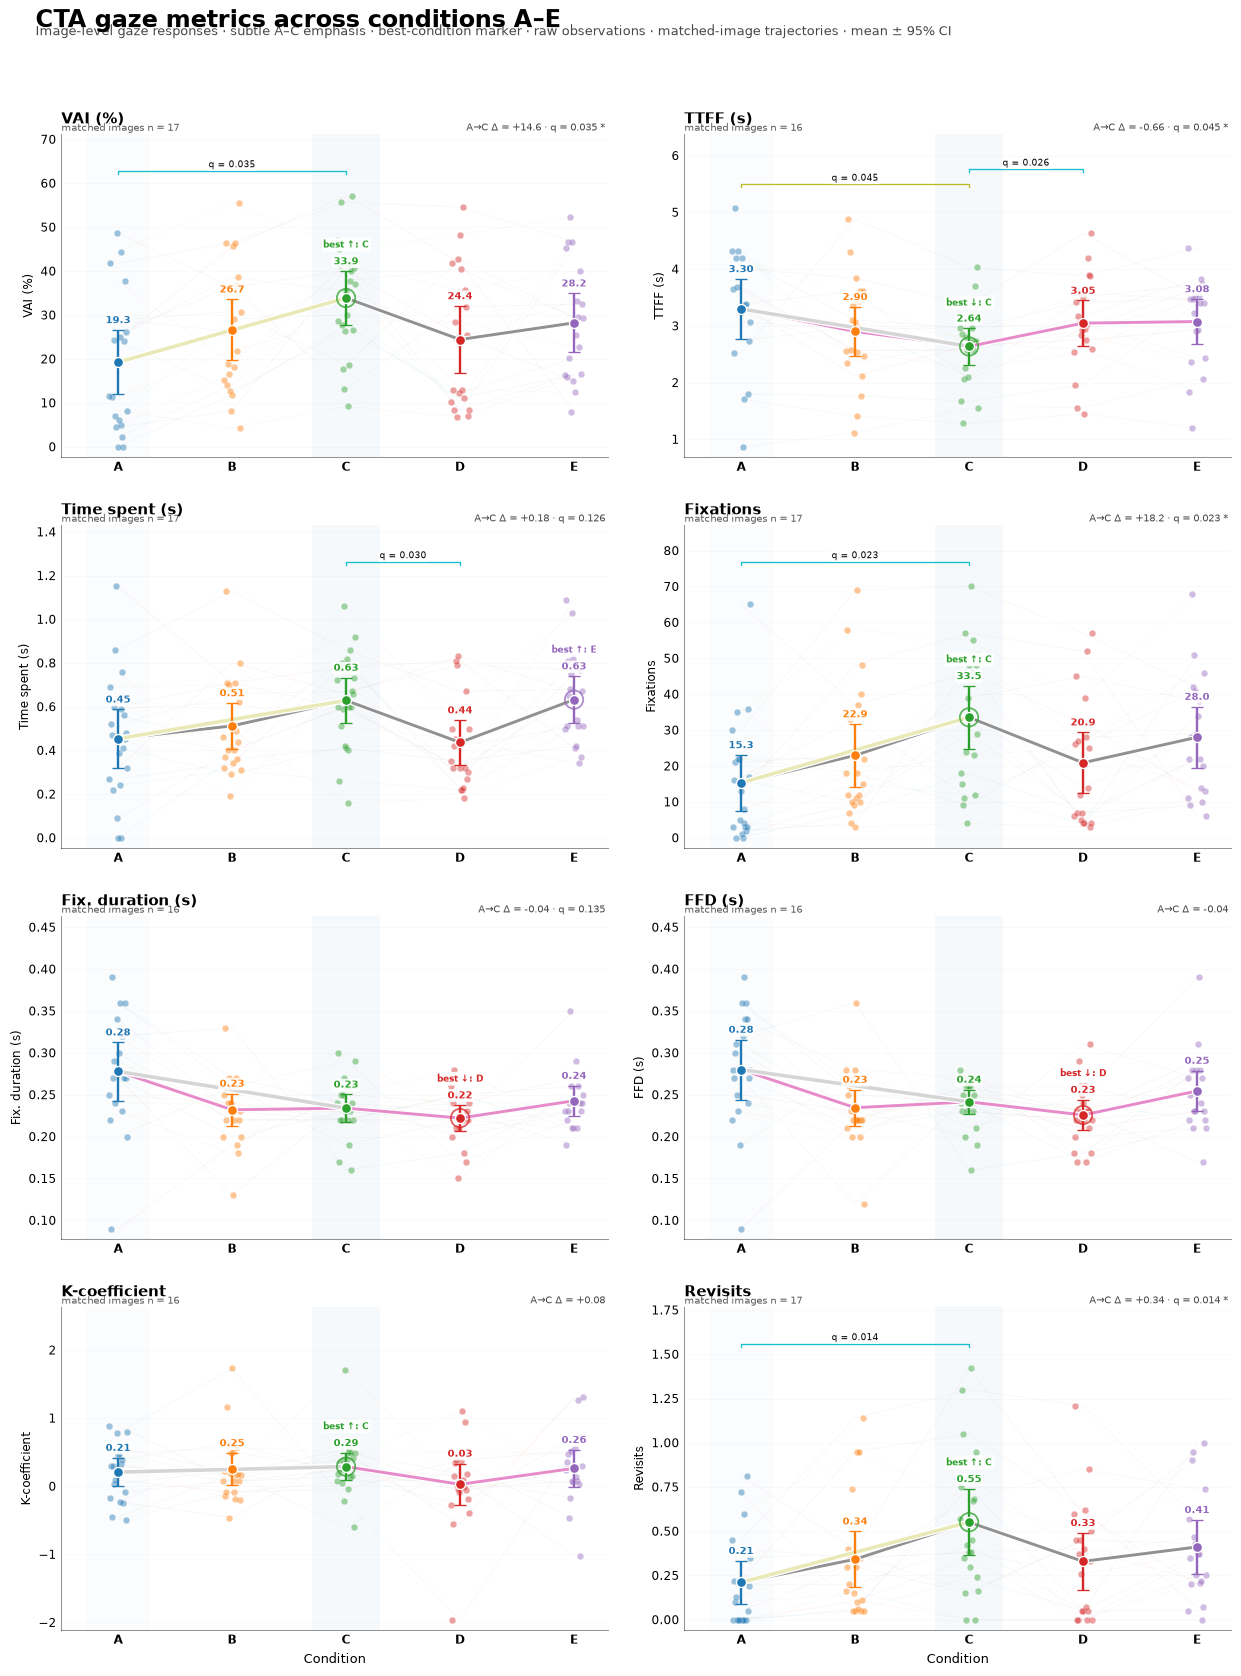

Saved: CTA_8metrics_AC_best.png
Saved: CTA_8metrics_AC_best.pdf

Creating figure for: Headline


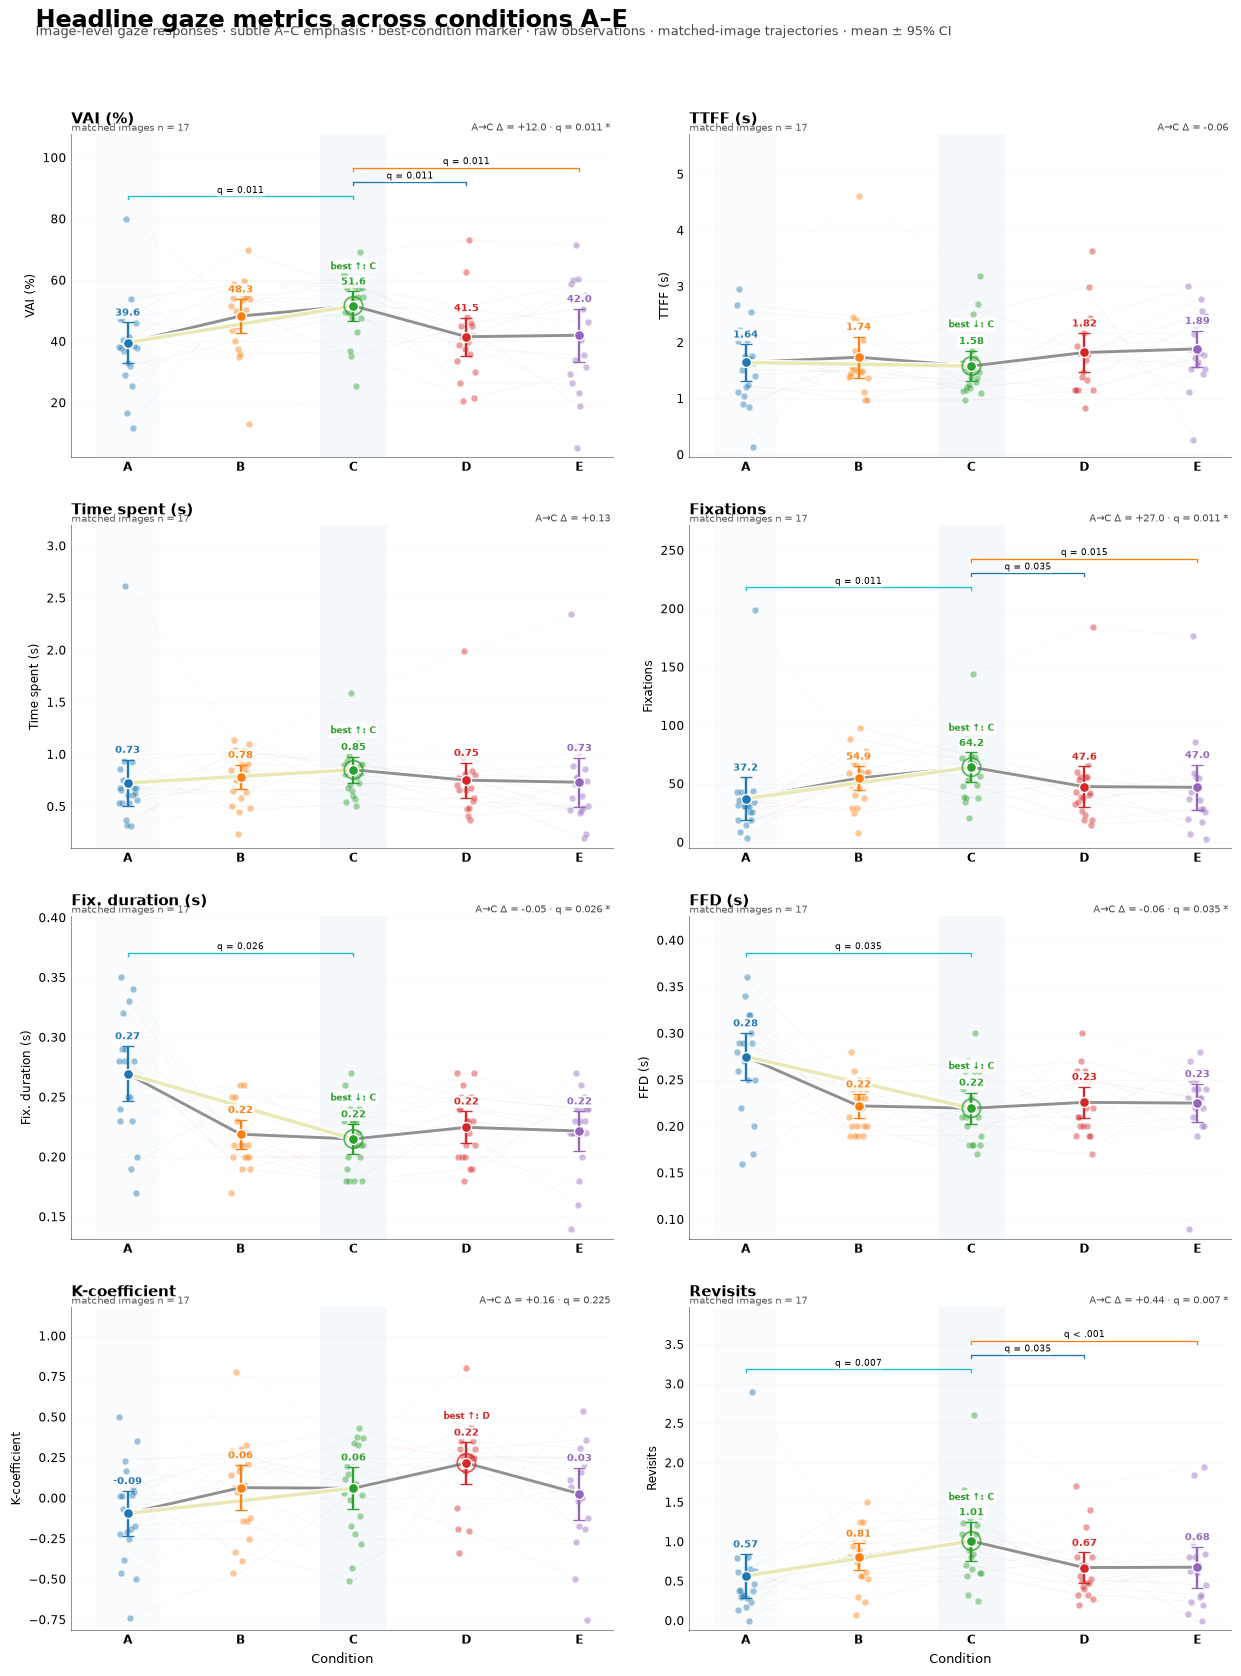

Saved: Headline_8metrics_AC_best.png
Saved: Headline_8metrics_AC_best.pdf

Creating figure for: Product


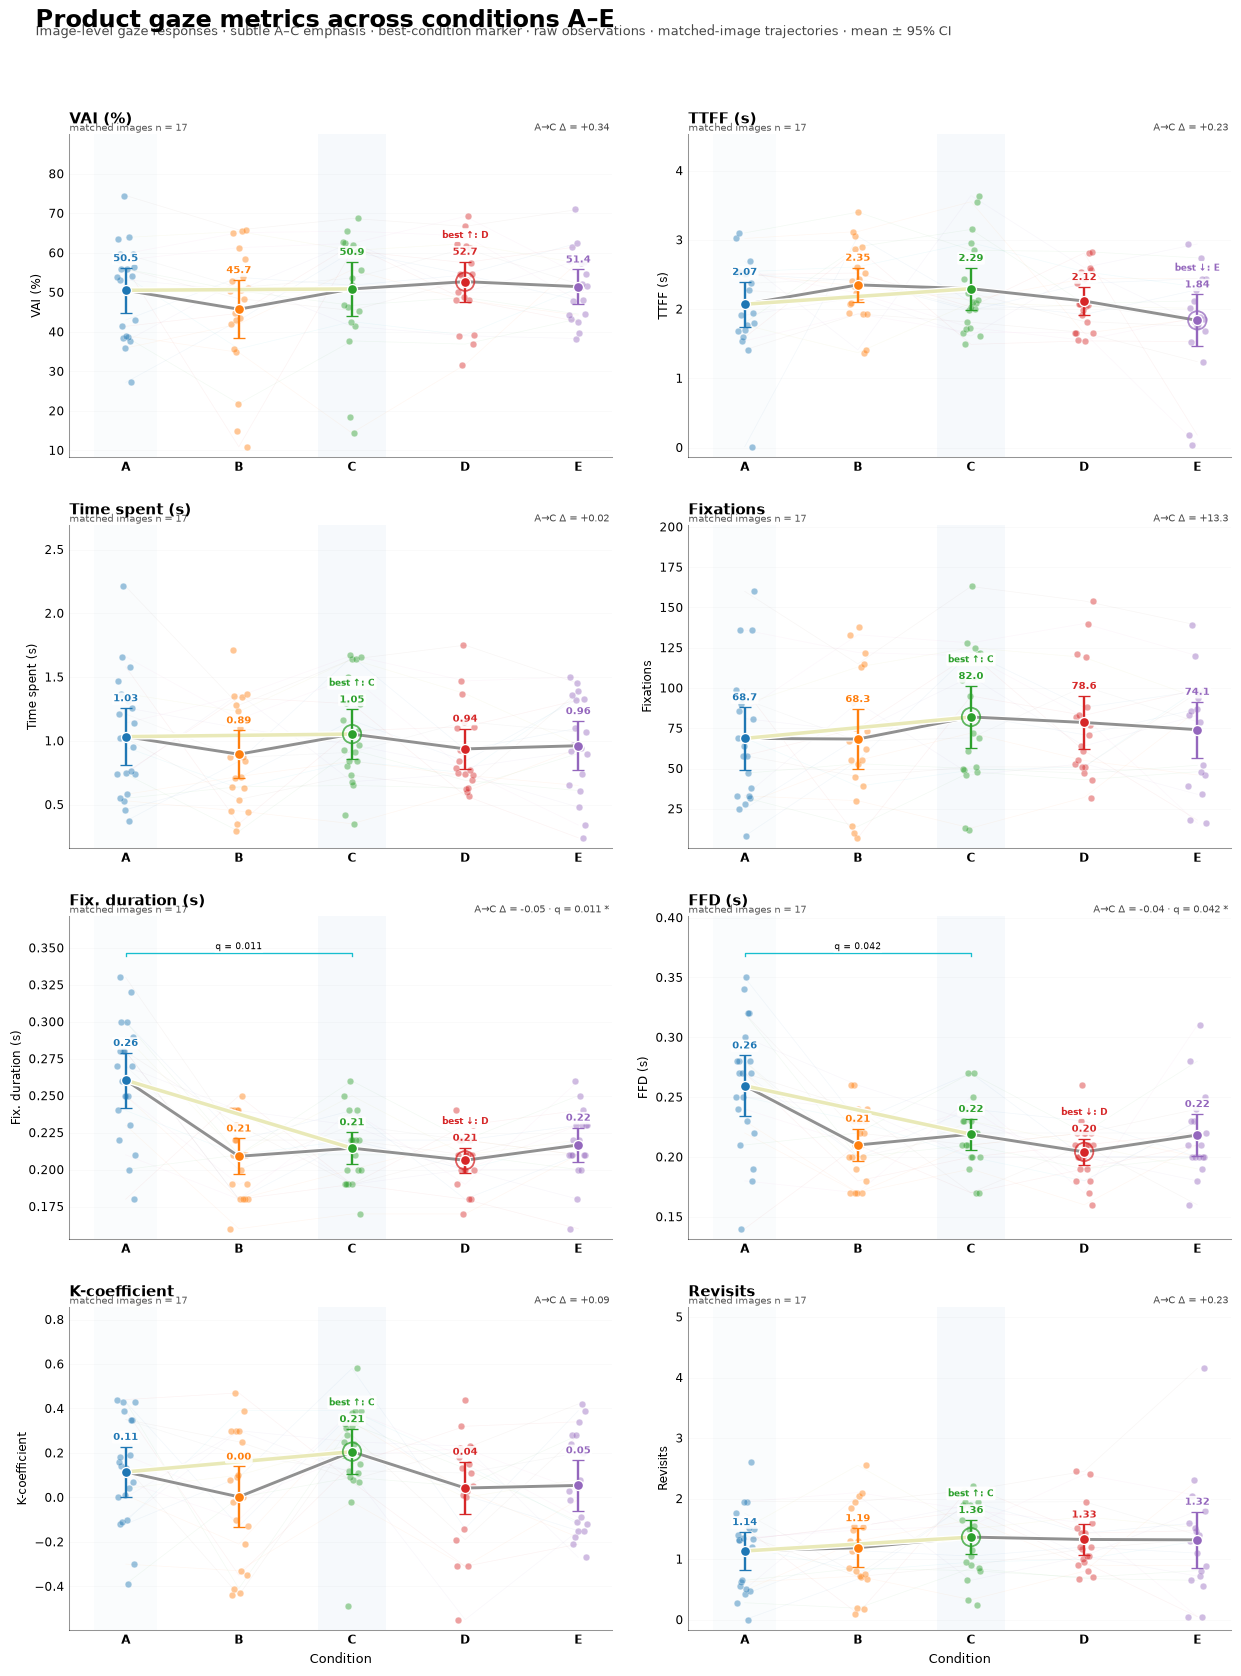

Saved: Product_8metrics_AC_best.png
Saved: Product_8metrics_AC_best.pdf


In [7]:
for aoi in AOIS:
    print("\nCreating figure for:", aoi)
    create_aoi_figure(aoi)


## Outputs

Running the last cell creates:

```text
CTA_8metrics_AC_best.pdf
Headline_8metrics_AC_best.pdf
Product_8metrics_AC_best.pdf
```

and the matching high-resolution PNGs.

### Important note about “best”
The notebook uses the `BETTER_DIRECTION` dictionary to decide what “best” means for each metric.

If you want a different interpretation for any metric, just edit:

```python
BETTER_DIRECTION = {
    ...
}
```
